<a href="https://colab.research.google.com/github/mohantyk/txt2img/blob/main/Chap6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/markhliu/txt2img
import sys
sys.path.append("/content/txt2img")

Cloning into 'txt2img'...
remote: Enumerating objects: 436, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 436 (delta 81), reused 52 (delta 52), pack-reused 351 (from 1)
Receiving objects: 100% (436/436), 88.66 MiB | 13.36 MiB/s, done.
Resolving deltas: 100% (213/213), done.


In [2]:
from torch import nn
import torch
import numpy as np
from tqdm import tqdm

In [3]:
class EmbedLayer(nn.Module):
  def __init__(self, input_dim, emb_dim):
    super().__init__()
    self.input_dim = input_dim
    layers = [nn.Linear(input_dim, emb_dim),
              nn.GELU(),
              nn.Linear(emb_dim, emb_dim)]
    self.model = nn.Sequential(*layers)

  def forward(self, x):
    x = x.view(-1, self.input_dim)
    return self.model(x)

In [4]:
timeembed1 = EmbedLayer(1, 512)
timeembed2 = EmbedLayer(1, 256)

timesteps = torch.tensor([25]).long()
t = timesteps/1000
temb1 = timeembed1(t).view(-1, 512, 1, 1)
temb2 = timeembed2(t).view(-1, 256, 1, 1)

temb1.shape, temb2.shape

(torch.Size([1, 512, 1, 1]), torch.Size([1, 256, 1, 1]))

In [5]:
n_classes = 10
contextembed1 = EmbedLayer(n_classes, 512)
contextembed2 = EmbedLayer(n_classes, 256)
label = torch.tensor([2, 9, 0]).long()

context_mask = torch.bernoulli(torch.zeros_like(label) + 0.1)
onehot = torch.nn.functional.one_hot(label, num_classes = n_classes).type(torch.float)

context_mask = context_mask[:, None]
context_mask = context_mask.repeat(1, n_classes)
context_mask = (-1 * (1-context_mask))
c = onehot * context_mask
cemb1 = contextembed1(c).view(-1, 512, 1, 1)
cemb2 = contextembed2(c).view(-1, 256, 1, 1)

cemb1.shape, cemb2.shape

(torch.Size([3, 512, 1, 1]), torch.Size([3, 256, 1, 1]))

In [6]:
img = torch.Tensor([[0, 1, 2, 3],
                    [1, 2, 3, 4],
                    [5, 4, 3, 2],
                    [3, 4, 7, 6]]).reshape(1,1,4,4)

maxpool = torch.nn.MaxPool2d(2)
out = maxpool(img)
out

tensor([[[[2., 4.],
          [5., 7.]]]])

In [7]:
image = torch.Tensor([[0, 1],
                      [1, 2]]).reshape(1, 1, 2, 2)
transconv = torch.nn.ConvTranspose2d(in_channels=1, out_channels=1, kernel_size=2, stride=2)
sd = transconv.state_dict()
weights = {'weight': torch.tensor([[[[1,2], [2,3]]]]), 'bias':torch.tensor([0])}
for k in sd:
  with torch.no_grad():
    sd[k].copy_(weights[k])

sd


OrderedDict([('weight',
              tensor([[[[1., 2.],
                        [2., 3.]]]])),
             ('bias', tensor([0.]))])

In [8]:
transoutput = transconv(image)
print(transoutput)

tensor([[[[0., 0., 1., 2.],
          [0., 0., 2., 3.],
          [1., 2., 2., 4.],
          [2., 3., 4., 6.]]]], grad_fn=<ConvolutionBackward0>)


In [9]:
class ResidualConvBlock(nn.Module):
  def __init__(self, in_channels, out_channels, is_res = False):
    super().__init__()
    self.same_channels = in_channels == out_channels
    self.is_res = is_res
    self.conv1 = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, 1, 1),
        nn.BatchNorm2d(out_channels),
        nn.GELU(),)
    self.conv2 = nn.Sequential(
        nn.Conv2d(out_channels, out_channels, 3, 1, 1),
        nn.BatchNorm2d(out_channels),
        nn.GELU(),)


  def forward(self, x):
    if self.is_res:
      x1 = self.conv1(x)
      x2 = self.conv2(x1)
      if self.same_channels:
        out = x + x2
      else:
        out = x1 + x2
      return out / 1.414

    else:
      x1 = self.conv1(x)
      x2 = self.conv2(x1)
      return x2


In [10]:
class UnetDown(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    layers = [ResidualConvBlock(in_channels, out_channels), nn.MaxPool2d(2)]
    self.model = nn.Sequential(*layers)

  def forward(self, x):
    return self.model(x)

In [11]:
class UnetUp(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    layers = [nn.ConvTranspose2d(in_channels, out_channels, 2, 2),
              ResidualConvBlock(out_channels, out_channels),
              ResidualConvBlock(out_channels, out_channels)]
    self.model = nn.Sequential(*layers)

  def forward(self, x, skip):
    x = torch.cat((x, skip), 1)
    x = self.model(x)
    return x

In [12]:
class Unet(nn.Module):
  def __init__(self, in_channels, n_feat = 256, n_classes=10):
    super().__init__()
    self.in_channels = in_channels
    self.n_feat = n_feat
    self.n_classes = n_classes

    self.init_conv = ResidualConvBlock(in_channels, n_feat, is_res=True)
    self.down1 = UnetDown(n_feat, n_feat)
    self.down2 = UnetDown(n_feat, 2 * n_feat)
    self.to_vec = nn.Sequential(nn.AvgPool2d(7), nn.GELU())
    self.timeembed1 = EmbedLayer(1, 2*n_feat)
    self.timeembed2 = EmbedLayer(1, 1*n_feat)
    self.contextembed1 = EmbedLayer(n_classes, 2*n_feat)
    self.contextembed2 = EmbedLayer(n_classes, 1*n_feat)

    self.up0 = nn.Sequential(nn.ConvTranspose2d(2*n_feat, 2*n_feat, 7, 7),
                             nn.GroupNorm(8, 2*n_feat),
                             nn.ReLU(),)
    self.up1 = UnetUp(4 * n_feat, n_feat)
    self.up2 = UnetUp(2 * n_feat, n_feat)
    self.out = nn.Sequential(nn.Conv2d(2 * n_feat, n_feat, 3, 1, 1),
                             nn.GroupNorm(8, n_feat), nn.ReLU(),
                             nn.Conv2d(n_feat, self.in_channels, 3, 1, 1))

  def forward(self, x, c, t, context_mask):
    x = self.init_conv(x)
    down1 = self.down1(x)
    down2 = self.down2(down1)
    hiddenvec = self.to_vec(down2)

    c = nn.functional.one_hot(c, num_classes = self.n_classes).type(torch.float)
    context_mask = context_mask[:, None]
    context_mask = context_mask.repeat(1, self.n_classes)
    context_mask = (-1 * (1-context_mask))
    c = c * context_mask

    cemb1 = self.contextembed1(c).view(-1, self.n_feat * 2, 1, 1)
    temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
    cemb2 = self.contextembed2(c).view(-1, self.n_feat, 1, 1)
    temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1)

    up1 = self.up0(hiddenvec)
    up2 = self.up1(cemb1 * up1 + temb1, down2)
    up3 = self.up2(cemb2 * up2 + temb2, down1)
    out = self.out(torch.cat((up3, x), 1))
    return out

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [14]:
def noise_scheduler(T):
    beta1, beta2 = 0.0001, 0.02
    beta_t = (beta2 - beta1) * torch.arange(0, T + 1,
                    dtype=torch.float32) / T + beta1
    sqrt_beta_t = torch.sqrt(beta_t)
    alpha_t = 1 - beta_t
    log_alpha_t = torch.log(alpha_t)
    alphabar_t = torch.cumsum(log_alpha_t, dim=0).exp()
    sqrtab = torch.sqrt(alphabar_t)
    oneover_sqrta = 1 / torch.sqrt(alpha_t)
    sqrtmab = torch.sqrt(1 - alphabar_t)
    mab_over_sqrtmab_inv = (1 - alpha_t) / sqrtmab
    return {"alpha_t": alpha_t,  # \alpha_t
        "oneover_sqrta": oneover_sqrta,  # 1/\sqrt{\alpha_t}
        "sqrt_beta_t": sqrt_beta_t,  # \sqrt{\beta_t}
        "alphabar_t": alphabar_t,  # \bar{\alpha_t}
        "sqrtab": sqrtab,  # \sqrt{\bar{\alpha_t}}
        "sqrtmab": sqrtmab,  # \sqrt{1-\bar{\alpha_t}}
        # (1-\alpha_t)/\sqrt{1-\bar{\alpha_t}}
        "mab_over_sqrtmab": mab_over_sqrtmab_inv,}

In [15]:
class DDPM(nn.Module):
  def __init__(self, model, n_T, device=device, drop_prob=0.1):
    super().__init__()
    self.model = model.to(device)
    for k, v in noise_scheduler(n_T).items():
      self.register_buffer(k, v)
    self.n_T = n_T
    self.device = device
    self.drop_prob = drop_prob
    self.loss_mse = nn.MSELoss()

  def forward(self, x, c):
    _ts = torch.randint(1, self.n_T+1, (x.shape[0],)).to(self.device)
    noise = torch.randn_like(x)
    x_t = (self.sqrtab[_ts, None, None, None] * x
          + self.sqrtmab[_ts, None, None, None] * noise)
    context_mask = torch.bernoulli(torch.zeros_like(c) + self.drop_prob).to(self.device)
    return self.loss_mse(noise,
                         self.model(x_t, c, _ts / self.n_T, context_mask))

In [16]:
@torch.no_grad()
def sample(ddpm, model, n_sample, size, device, guide_w=0.0, step_size=1):
  x_i = torch.randn(n_sample, *size).to(device)
  c_i = torch.arange(0, 10).to(device)
  c_i = c_i.repeat(int(n_sample/c_i.shape[0]))
  context_mask = torch.zeros_like(c_i).to(device)
  c_i = c_i.repeat(2)
  context_mask = context_mask.repeat(2)
  # The second half of the labels are masked
  context_mask[n_sample:] = 1.
  x_i_store = []
  for i in range(ddpm.n_T, 0, -step_size):
    t_is = torch.tensor([i / ddpm.n_T]).to(device)
    t_is = t_is.repeat(n_sample, 1, 1, 1)
    x_i = x_i.repeat(2, 1, 1, 1)
    t_is = t_is.repeat(2, 1, 1, 1)
    z = torch.randn(n_sample, *size).to(device) if i>1 else 0
    eps = model(x_i, c_i, t_is, context_mask)
    # conditional generation
    eps1 = eps[:n_sample]
    # unconditional generation
    eps2 = eps[n_sample:]
    # output is a mix of conditional and unconditional generation
    eps = (1+guide_w) * eps1 - guide_w * eps2
    x_i = x_i[:n_sample]
    x_i = (ddpm.oneover_sqrta[i] * (x_i - eps * ddpm.mab_over_sqrtmab[i])
          + ddpm.sqrt_beta_t[i]  * z)
    if i % 20 == 0 or i == ddpm.n_T or i < 8:
      x_i_store.append(x_i.detach().cpu().numpy())
  x_i_store = np.array(x_i_store)
  return x_i, x_i_store

In [17]:
from torchvision import transforms, datasets

In [18]:
torch.manual_seed(42)
tf = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Lambda(lambda x: 2*(x-0.5)),])
dataset = datasets.FashionMNIST(
    r'.', train=True, download=True, transform=tf
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.09MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.4MB/s]


In [19]:
text_labels=['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

In [20]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

In [21]:
import os
os.makedirs("files", exist_ok=True)


In [22]:
n_epoch = 20
n_T = 1000
n_classes = 10
n_feat = 256
lrate = 0.00001
model = Unet(in_channels=1, n_feat=n_feat, n_classes=n_classes)
ddpm = DDPM(model, n_T=n_T).to(device)
optim = torch.optim.Adam(ddpm.parameters(), lr=lrate)

In [23]:

scaler = torch.amp.GradScaler(device)
for ep in range(n_epoch):
  print(f'epoch {ep}')
  ddpm.train()
  optim.param_groups[0]['lr'] = lrate * (1-ep/n_epoch)
  pbar = tqdm(dataloader)
  loss_ema = None
  for x, c in pbar:
    x = x.to(device)
    c = c.to(device)
    with torch.amp.autocast(device):
      loss = ddpm(x, c)
    optim.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optim)
    scaler.update()
    if loss_ema is None:
      loss_ema = loss.item()
    else:
      loss_ema = 0.95 * loss_ema + 0.05 * loss.item()
    pbar.set_description(f'loss: {loss_ema:.4f}')

torch.save(model.state_dict(), "files/conditional.pth")

epoch 0


loss: 0.0947: 100%|██████████| 235/235 [02:38<00:00,  1.48it/s]


epoch 1


loss: 0.0726: 100%|██████████| 235/235 [02:39<00:00,  1.47it/s]


epoch 2


...

loss: 0.0505: 100%|██████████| 235/235 [02:36<00:00,  1.50it/s]


epoch 18


loss: 0.0473: 100%|██████████| 235/235 [02:36<00:00,  1.50it/s]


epoch 19


loss: 0.0500: 100%|██████████| 235/235 [02:36<00:00,  1.50it/s]


## Generation

In [23]:
x, c = next(iter(dataloader))
x, c = x.to(device), c.to(device)
ddpm.eval()
n_sample = n_classes
x_gen, x_gen_store = sample(ddpm, model, n_sample, (1,28,28), device, guide_w=2)
x_real = torch.Tensor(x_gen.shape).to(device)
for k in range(n_classes):
  try:
    idx = torch.squeeze((c==k).nonzero())[0]
  except:
    idx = 0
  x_real[k] = x[idx]
x_all = torch.cat([x_gen, x_real])

NameError: name 'x_all' is not defined

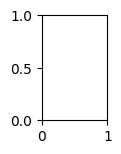

In [24]:
captions=[]
for i in range(20):
    gen="Generated" if i<10 else "Real"
    num=i%10
    label_and_num=f"{gen}\n{text_labels[num]} ({num})"
    captions.append(label_and_num)  #1
from matplotlib import pyplot as plt
plt.figure(figsize=(10,3),dpi=100)
for i in range(20):  #2
    plt.subplot(2,10,i+1)
    plt.imshow(x_all[i].cpu().permute(1,2,0)/2+0.5,
               cmap="binary")
    plt.axis('off')
    plt.title(captions[i],fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
n_sample  = 4*n_classes
x_gen,x_gen_store=sample(ddpm,model,n_sample,(1,28,28),
                              device,guide_w=5)  #1
plt.figure(figsize=(10,5),dpi=100)
for i in range(40):  #2
    plt.subplot(4,10,i+1)
    plt.imshow(x_gen[i].cpu().permute(1,2,0)/2+0.5,
               cmap="binary")
    plt.axis('off')
    c=i%10
    plt.title(f"{text_labels[c]} ({c})",fontsize=10)
plt.tight_layout()
plt.show()